In [ ]:
from modelscope.utils.constant import Tasks
from modelscope.pipelines import pipeline
import cv2

pipe = pipeline(task=Tasks.text_to_image_synthesis, 
                model='AI-ModelScope/stable-diffusion-v1-5',
                model_revision='v1.0.0')

prompt = '飞流直下三千尺，油画'
output = pipe({'text': prompt})
cv2.imwrite('result.png', output['output_imgs'][0])



In [ ]:
from modelscope.utils.constant import Tasks
from modelscope.pipelines import pipeline
import cv2

pipe = pipeline(task=Tasks.text_to_image_synthesis, 
                model='AI-ModelScope/stable-diffusion-xl-base-1.0',
                use_safetensors=True,
                model_revision='v1.0.0')

prompt = "Beautiful and cute girl, 16 years old, denim jacket, gradient background, soft colors, soft lighting, cinematic edge lighting, light and dark contrast, anime, art station Seraflur, blind box, super detail, 8k"
output = pipe({'text': prompt})
cv2.imwrite('SDXL.png', output['output_imgs'][0])

In [1]:
import pickle
with open("/media/ubuntu/sda/TrippleN/customize/all_subjects_unit_info.pkl",'rb')as f:
    a = pickle.load(f)

In [2]:
import numpy as np
import h5py
import pandas as pd
from pycocotools.coco import COCO
import torch
from torchvision import models, transforms
from PIL import Image
import open_clip
import pickle
import os
import warnings
import tqdm

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
STIMULI_HDF5 = '/media/ubuntu/sda/TrippleN/nsd_stimuli.hdf5'
STIMULI_CSV = '/media/ubuntu/sda/TrippleN/nsd_stim_info_merged.csv'
COCO_DIR = '/media/ubuntu/sda/TrippleN/coco'
CLIP_MODEL_PATH = '/media/ubuntu/sda/TrippleN/model/ViT-L-14.pt'
OUTPUT_DIR = '/media/ubuntu/sda/TrippleN/customize'

CLIP_TEXT_DIM = 768
ALEXNET_FC6_DIM = 4096

In [3]:
def load_stimuli_info(csv_path):
    """加载NSD刺激物信息CSV文件"""
    print(f"加载刺激物信息: {csv_path}")
    df = pd.read_csv(csv_path, index_col=0)
    print(f"  总样本数: {len(df)}")
    print(f"  train2017: {(df['cocoSplit'] == 'train2017').sum()}")
    print(f"  val2017: {(df['cocoSplit'] == 'val2017').sum()}")
    return df

In [6]:
from pycocotools.coco import COCO
# 加载 COCO 数据集
annotation_file = '/media/ubuntu/sda/TrippleN/coco/annotations/instances_train2017.json'
coco = COCO(annotation_file)
# 获取特定类别和图像的标注 ID
imgIds = coco.getImgIds(imgIds = [412922])
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

loading annotations into memory...
Done (t=8.33s)
creating index...
index created!


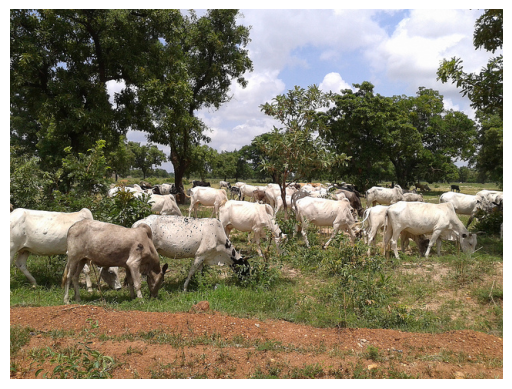

In [8]:
import matplotlib.pyplot as plt
from skimage import io  # scikit-learn 包
I = io.imread(img['coco_url'])
plt.axis('off')
plt.imshow(I)
plt.show()

In [5]:
image = load_images_from_hdf5(hdf5_path=STIMULI_HDF5, indices=412922)

加载HDF5图片数据: /media/ubuntu/sda/TrippleN/nsd_stimuli.hdf5


IndexError: Index (412922) out of range for (0-72999)

In [2]:
import numpy as np

In [ ]:
z = np.load("trial_averaged_sub01.npz", allow_pickle=True)


In [60]:
a = np.load("/media/ubuntu/sda/TrippleN/human_fMRI/trial_averaged_sub01_func1pt8mm.npz", allow_pickle=True)

In [61]:
a.keys()

KeysView(NpzFile '/media/ubuntu/sda/TrippleN/human_fMRI/trial_averaged_sub01_func1pt8mm.npz' with keys: allow_pickle, newdata, newdatastim, voxel_info, roi_type_names...)

In [71]:
b = a['newdatastim_73k']

In [63]:
c = a['voxel_info']

In [64]:
import pandas as pd

In [65]:
c = pd.DataFrame(c, columns=a['roi_type_names'])